# PRÁCTICA 2 PLN
# Desarrollo de una aplicación de Procesamiento del Lenguaje Natural

Alumnos:

Javier García Fernández

Miguel Ángel Véliz Ayala

# 5. Resumen Automático Abstractivo

In [ ]:
import json
import re
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import nltk
from nltk.tokenize import sent_tokenize
import requests
import os
from tqdm import tqdm
import random

In [ ]:
# Descargar recursos de NLTK necesarios para tokenización de oraciones
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

Debido a limitaciones en el uso de recursos de GPU (hemos utilizado Google Colab para ejecutar la práctica), no es posible procesar todos los archivos JSON simultáneamente. Por esta razón, en la función *load_json_files()* se han comentado las rutas de los archivos, permitiendo ejecutar el procesamiento de los hilos uno a uno. Este enfoque nos ha llevado a ejecutar el mismo procedimiento siete veces, una por cada fichero, para garantizar que todos los hilos fueran procesados correctamente sin exceder los recursos disponibles.

In [ ]:
# Función para cargar los archivos JSON (reutilizada del ejercicio anterior)
def load_json_files():
    data = {}
    json_files = [
        #'comments_sports.json',
        #'comments_soccer.json',
        #'comments_nfl.json',
        #'comments_cricket.json',
        #'comments_formula1.json',
        #'comments_hockey.json',
        #'comments_nba.json'
    ]

    for file_name in json_files:
        subreddit = file_name.replace('comments_', '').replace('.json', '')
        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                data[subreddit] = json.load(f)
            print(f"Cargado {file_name}: {len(data[subreddit])} hilos")
        except FileNotFoundError:
            print(f"Advertencia: No se encontró el archivo {file_name}")

    return data

# Función para preprocesar texto
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '<URL>', text, flags=re.MULTILINE)
    # Eliminar caracteres especiales manteniendo letras, números y espacios
    text = re.sub(r'@\w+', '<USER>', text)
    # Eliminar números
    text = re.sub(r'\d+', '<NUM>', text)
    # Eliminar todos los caracteres que no sean letras, números o espacios
    text = re.sub(r'[^\w\s]', '', text)
    # Reemplazar múltiples espacios por uno solo
    text = re.sub(r'\s+', ' ', text)
    # Eliminar espacios al inicio y final
    text = text.strip()
    return text

Para generar el resumen de cada hilo, hemos utilizado una función que concatena el título, la descripción y todos los comentarios asociados al hilo en un único texto. Esta concatenación permite que el modelo tenga una visión más completa del contenido del hilo, capturando tanto la idea principal planteada por el autor como las opiniones y reacciones expresadas por la comunidad en los comentarios. De este modo, se obtiene un resumen más representativo y contextualizado del hilo completo.

In [ ]:
# Función para concatenar el texto completo de un hilo (título + descripción + comentarios)
def get_thread_full_text(thread):
    title = thread.get('title', '')
    description = thread.get('description', '')

    # Concatenar comentarios
    comments_text = ""
    for comment in thread.get('comments', []):
        comment_text = comment.get('comment', '')
        if comment_text:
            comments_text += " " + comment_text

    # Unir todo
    full_text = f"{title} {description} {comments_text}".strip()
    return full_text

## 5.1 Usar un modelo ya entrenado para esta tarea, como *mT5_multilingual_XLSum* y guardar el resumen de la descripción del hilo en el fichero JSON.

In [ ]:
# 5.1) Resumen con mT5_multilingual_XLSum
def summarize_with_mt5(text, max_length=150, min_length=30):
    # Cargar el modelo y tokenizador
    try:
        tokenizer = AutoTokenizer.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")
        model = AutoModelForSeq2SeqLM.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")

        # Truncar texto si es muy largo (límite de tokens de mT5)
        inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True)

        # Generar resumen
        with torch.no_grad():
            summary_ids = model.generate(
                inputs["input_ids"],
                max_length=max_length,
                min_length=min_length,
                num_beams=4,
                length_penalty=2.0,
                early_stopping=True
            )

        # Decodificar resumen
        summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        return summary
    except Exception as e:
        print(f"Error al generar resumen con mT5: {e}")
        return "Error al generar resumen"

In [ ]:
# Verificar la configuración del token
from google.colab import userdata
from huggingface_hub import login, whoami

# Intentar autenticación
try:
    token = userdata.get('HF_TOKEN')
    login(token=token)
    user_info = whoami()
    print(f"✅ Autenticado correctamente como: {user_info}")
    print(f"Organización: {user_info.get('orgs', [])}")
except Exception as e:
    print(f"❌ Error en la autenticación: {e}")

❌ Error en la autenticación: Secret HF_TOKEN does not exist.


In [ ]:
from huggingface_hub import snapshot_download
import os

# Intentar descargar solo Gemma para probar
try:
    print("Descargando modelo Gemma-2b...")
    gemma_path = snapshot_download(
        repo_id="google/gemma-2b",
        local_dir="./models/gemma",
        token=userdata.get('HF_TOKEN')
    )
    print(f"✅ Gemma descargado correctamente en: {gemma_path}")
    print(f"Archivos: {os.listdir(gemma_path)}")
except Exception as e:
    print(f"❌ Error detallado: {e}")  # En la última ejecución que hemos realizado (la Evaluación Cualitativa no ha hecho falta el token)

    # Verificar conexión de internet
    print("\nVerificando conexión a internet...")
    !ping -c 3 huggingface.co

Descargando modelo Gemma-2b...
❌ Error detallado: Secret HF_TOKEN does not exist.

Verificando conexión a internet...
/bin/bash: line 1: ping: command not found


## 5.2 Usar un SLM como Gemma (2B) para obtener el resumen mediante una estrategia (Zero-shot Learning, aprendizaje sin ejemplos).

In [ ]:
# 5.2) Función optimizada para resumir textos usando Gemma (modo offline)
def summarize_with_slm(text, model_name="gemma"):
    try:
        # Importaciones necesarias
        from transformers import AutoModelForCausalLM, AutoTokenizer
        import torch
        import os

        # Configuración para modo offline
        MODEL_DIR = "./models/gemma"

        # Verificar que el directorio existe
        if not os.path.exists(MODEL_DIR):
            raise ValueError(f"El directorio {MODEL_DIR} no existe. Asegúrate de haber descargado el modelo.")

        # Uso de variables globales para cargar el modelo solo una vez
        global tokenizer, model

        # Si el modelo y tokenizer ya están cargados, no los volvemos a cargar
        if 'tokenizer' not in globals() or 'model' not in globals():
            device = "cuda" if torch.cuda.is_available() else "cpu"
            print(f"Usando dispositivo: {device}")

            print(f"Cargando tokenizer en modo offline desde {MODEL_DIR}...")
            tokenizer = AutoTokenizer.from_pretrained(
                MODEL_DIR,
                local_files_only=True
            )

            print(f"Cargando modelo en modo offline desde {MODEL_DIR}...")
            model_kwargs = {
                "device_map": "auto",
                "local_files_only": True,
                "torch_dtype": torch.float16,
                # Mejora la velocidad sacrificando algo de precisión
                "low_cpu_mem_usage": True
            }

            model = AutoModelForCausalLM.from_pretrained(
                MODEL_DIR,
                **model_kwargs
            )
        else:
            print("Utilizando modelo y tokenizer previamente cargados")

        device = next(model.parameters()).device

        # Limitar el texto de entrada para hacer el proceso más rápido
        MAX_INPUT_LENGTH = 400  # Ajusta según necesidad
        if len(text) > MAX_INPUT_LENGTH:
            text = text[:MAX_INPUT_LENGTH] + "..."

        # Prompt más conciso
        prompt = f"<start_of_turn>user\nResume brevemente: {text}<end_of_turn>\n<start_of_turn>model\n"

        # Tokenización eficiente
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=450)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Configuración optimizada para generación más rápida
        with torch.no_grad():
            output_sequences = model.generate(
                inputs["input_ids"],
                max_new_tokens=40,           # Reducido para generar menos tokens
                temperature=0.3,             # Reducido para menos aleatoriedad
                top_p=0.85,
                do_sample=False,            # Desactivado para mayor velocidad
                num_beams=1,                # Sin beam search para mayor velocidad
                early_stopping=True,        # Detener cuando sea posible
                pad_token_id=tokenizer.eos_token_id
            )

        # Decodificar solo el resultado
        full_output = tokenizer.decode(output_sequences[0], skip_special_tokens=True)

        # Proceso mejorado para extraer el resumen
        # Extraer solo la respuesta del modelo
        if "<start_of_turn>model" in full_output:
            summary = full_output.split("<start_of_turn>model")[1].strip()
        elif "Resumen:" in full_output:
            summary = full_output.split("Resumen:")[1].strip()
        elif "Resume brevemente:" in full_output:
            summary = full_output.split("Resume brevemente:")[1].strip()
        else:
            # Caso de fallback: tomar solo la última parte
            text_preview = text[:30] + "..." if len(text) > 30 else text
            parts = full_output.split(text_preview)
            if len(parts) > 1:
                summary = parts[-1].strip()
            else:
                summary = full_output

        return summary

    except Exception as e:
        print(f"Error al generar resumen con Gemma: {str(e)}")
        # Retornar un resumen genérico en caso de error
        return "No se pudo generar un resumen debido a un error."

En esta sección, hemos implementado una función optimizada para generar resúmenes utilizando un Small Large Model (SLM), concretamente Gemma, en modo offline, siguiendo un enfoque de Zero-shot Learning (sin ejemplos previos). La función toma como entrada el texto completo del hilo compuesto por el título, la descripción y los comentarios, aplica un prompt conciso, y genera un resumen breve. Para adaptarnos a las limitaciones de recursos, se ha limitado la longitud de entrada y se han ajustado los parámetros de generación para priorizar la velocidad y eficiencia. Además, se ha incorporado un proceso de post-procesamiento para extraer únicamente la parte relevante del texto generado por el modelo.


Después de generar el resumen con el modelo Gemma, se aplica una función de post-procesamiento y clasificación binaria para evaluar la calidad del resumen. Esta función realiza una limpieza básica del texto y, mediante una serie de criterios simples pero efectivos, clasifica el resumen como válido (1) si es informativo, coherente y presenta una longitud mínima aceptable, o como no válido (0) si resulta demasiado corto, poco claro o incompleto. Esta evaluación permite identificar resúmenes útiles y descartar aquellos que no cumplen un mínimo de calidad, cumpliendo así con el requisito de clasificar la salida del modelo dentro de un enfoque binario.

In [ ]:
# Función para post-procesamiento y clasificación binaria de resúmenes
def postprocess_and_classify_summary(summary):
    # Esta función aplica un post-procesamiento al resumen y lo clasifica
    # en un enfoque binario, de la siguiente forma:
    # - 1: Resumen de alta calidad (informativo y coherente)
    # - 0: Resumen de baja calidad o incompleto

    # Limpieza básica
    summary = summary.strip()

    # Criterios simples para clasificación binaria
    if len(summary) < 20:  # Resumen demasiado corto
        return summary, 0

    if len(summary.split()) < 10:  # Menos de 10 palabras
        return summary, 0

    # Verificar si hay oraciones completas (terminan con punto)
    if not re.search(r'[.!?]', summary):
        return summary, 0

    # Si llega aquí, consideramos que es un resumen aceptable
    return summary, 1

## Función Principal

In [ ]:
# Función principal optimizada para procesar todos los hilos
def process_threads_for_summarization(num_threads=None, batch_size=5):
    import json
    from tqdm import tqdm
    import time
    import os

    # Inicializar los modelos una sola vez
    print("Inicializando modelos...")
    try:
        # Inicializar Gemma con un texto pequeño de prueba
        _ = summarize_with_slm("Texto de prueba para inicializar Gemma")
        print("Modelo Gemma inicializado")

        # También podemos inicializar mT5 si se usa
        _ = summarize_with_mt5("Texto de prueba para inicializar mT5")
        print("Modelo mT5 inicializado")
    except Exception as e:
        print(f"Error al inicializar modelos: {e}")
        return

    # Cargar los datos
    data = load_json_files()

    # Procesar cada subreddit
    for subreddit, threads in data.items():
        print(f"\nProcesando hilos de {subreddit}...")

        # Limitar el número de hilos si se especifica
        if num_threads:
            threads_to_process = threads[:num_threads]
        else:
            threads_to_process = threads

        print(f"Se procesarán {len(threads_to_process)} hilos en lotes de {batch_size}")

        # Procesamiento por lotes para mejorar rendimiento
        for batch_start in range(0, len(threads_to_process), batch_size):
            batch_end = min(batch_start + batch_size, len(threads_to_process))
            batch = threads_to_process[batch_start:batch_end]

            print(f"Procesando lote {batch_start//batch_size + 1} de {(len(threads_to_process)-1)//batch_size + 1}")

            # Procesar cada hilo del lote actual
            for i, thread in enumerate(tqdm(batch, desc=f"Hilos de {subreddit}")):
                # Obtener texto completo del hilo
                full_text = get_thread_full_text(thread)

                if not full_text:
                    continue

                thread_id = thread.get("id", str(i))

                try:
                    # 5.2) Generar resumen con Gemma (primero para aprovechar el modelo ya cargado)
                    start_time = time.time()
                    gemma_summary = summarize_with_slm(full_text)
                    gemma_time = time.time() - start_time

                    # 5.1) Generar resumen con mT5
                    start_time = time.time()
                    mt5_summary = summarize_with_mt5(full_text)
                    mt5_time = time.time() - start_time

                    # Post-procesamiento (en paralelo sería ideal, pero mantenemos secuencial por simplicidad)
                    mt5_summary_processed, mt5_quality = postprocess_and_classify_summary(mt5_summary)
                    gemma_summary_processed, gemma_quality = postprocess_and_classify_summary(gemma_summary)

                    # Guardar resúmenes en el hilo
                    thread["mt5_summary"] = mt5_summary_processed
                    thread["mt5_quality"] = mt5_quality
                    thread["mt5_time"] = round(mt5_time, 2)
                    thread["slm_summary"] = gemma_summary_processed
                    thread["slm_quality"] = gemma_quality
                    thread["slm_time"] = round(gemma_time, 2)

                    # Actualizar el hilo en la lista original
                    global_index = threads.index(thread) if thread in threads else -1
                    if global_index >= 0:
                        threads[global_index] = thread

                except Exception as e:
                    print(f"Error al procesar hilo {thread_id}: {str(e)}")
                    continue

            # Guardar resultados parciales después de cada lote
            output_file = f'comments_{subreddit}_summarized.json'
            try:
                with open(output_file, 'w', encoding='utf-8') as f:
                    json.dump(threads, f, ensure_ascii=False, indent=2)
                print(f"Resúmenes parciales guardados en {output_file}")
            except Exception as e:
                # Crear copia de seguridad en caso de error al guardar
                backup_file = f'comments_{subreddit}_summarized_backup_{int(time.time())}.json'
                with open(backup_file, 'w', encoding='utf-8') as f:
                    json.dump(threads, f, ensure_ascii=False)
                print(f"Error al guardar principal, backup creado: {backup_file}")

            # Pequeña pausa entre lotes
            time.sleep(1)

        print(f"Procesamiento de {subreddit} completado. Resúmenes guardados.")

    print("\nProceso completado para todos los subreddits.")

In [ ]:
# Necesitamos otra función que carge los ficheros json pero
# ahora la versión resumida
def load_json_files_v2():
    data = {}
    json_files = [
        'comments_cricket_summarized.json'
        'comments_formula1_summarized.json'
        'comments_hockey_summarized.json',
        'comments_nba_summarized.json',
        'comments_nfl_summarized.json',
        'comments_soccer_summarized.json',
        'comments_sports_summarized.json'
    ]

    for file_name in json_files:
        subreddit = file_name.replace('comments_', '').replace('_summarized.json', '')
        try:
            with open(file_name, 'r', encoding='utf-8') as f:
                data[subreddit] = json.load(f)
            print(f"Cargado {file_name}: {len(data[subreddit])} hilos")
        except FileNotFoundError:
            print(f"Advertencia: No se encontró el archivo {file_name}")

    return data

In [ ]:
# Función para seleccionar y evaluar 10 hilos aleatoriamente
def evaluate_sample_summaries(num_samples=10):
    data = load_json_files_v2()
    all_summarized_threads = []

    # Recopilar hilos con resúmenes
    for subreddit, threads in data.items():
        for thread in threads:
            if "mt5_summary" in thread and "slm_summary" in thread:
                all_summarized_threads.append({
                    "subreddit": subreddit,
                    "title": thread["title"],
                    "mt5_summary": thread["mt5_summary"],
                    "mt5_quality": thread.get("mt5_quality", None),
                    "slm_summary": thread["slm_summary"],
                    "slm_quality": thread.get("slm_quality", None)
                })

    # Seleccionar aleatoriamente 10 hilos
    selected_threads = random.sample(all_summarized_threads, min(num_samples, len(all_summarized_threads)))

    # Crear informe de evaluación
    evaluation_report = []
    for i, thread in enumerate(selected_threads):
        # Determinar automáticamente el mejor modelo basado en la clasificación binaria
        best_model = None
        if thread.get("mt5_quality", 0) > thread.get("slm_quality", 0):
            best_model = "mT5"
        elif thread.get("slm_quality", 0) > thread.get("mt5_quality", 0):
            best_model = "SLM"
        else:
            best_model = "Empate"

        evaluation_report.append({
            "thread_num": i+1,
            "subreddit": thread["subreddit"],
            "title": thread["title"],
            "mt5_summary": thread["mt5_summary"],
            "mt5_quality": thread.get("mt5_quality", None),
            "slm_summary": thread["slm_summary"],
            "slm_quality": thread.get("slm_quality", None),
            "best_model_auto": best_model,
            "evaluation": {
                "mt5_quality_manual": None,  # Para rellenar manualmente
                "slm_quality_manual": None,  # Para rellenar manualmente
                "best_model_manual": None    # Para rellenar manualmente
            }
        })

    # Guardar informe para evaluación manual
    with open('summary_evaluation_samples.json', 'w', encoding='utf-8') as f:
        json.dump(evaluation_report, f, ensure_ascii=False, indent=2)

    print(f"Informe de evaluación guardado en 'summary_evaluation_samples.json'")

    # Imprimir los resultados para evaluación cualitativa
    print("\n===== EVALUACIÓN CUALITATIVA DE RESÚMENES =====")
    for i, thread in enumerate(evaluation_report):
        print(f"\n--- Muestra {i+1} ({thread['subreddit']}) ---")
        print(f"Título: {thread['title']}")
        print(f"\nmT5 (Calidad: {thread['mt5_quality']}): {thread['mt5_summary']}")
        print(f"\nSLM (Calidad: {thread['slm_quality']}): {thread['slm_summary']}")
        print(f"\nMejor modelo (automático): {thread['best_model_auto']}")
        print("-" * 50)

In [ ]:
!pip install --upgrade torch transformers

In [ ]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
!nvidia-smi

Sun May 18 10:46:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Versión de CUDA: {torch.version.cuda}")

CUDA disponible: True
Versión de CUDA: 11.8


In [ ]:
import os
MODEL_DIR = "./models/gemma"
if os.path.exists(MODEL_DIR):
    print(f"Archivos en {MODEL_DIR}: {os.listdir(MODEL_DIR)}")
else:
    print(f"El directorio {MODEL_DIR} no existe. Debes descargarlo primero.")


El directorio ./models/gemma no existe. Debes descargarlo primero.


In [ ]:
import torchvision
from torchvision.ops import nms

In [ ]:
# Código para verificar el modelo localmente (puedes ejecutar esto separadamente)
def verify_local_model():
    import os

    MODEL_DIR = "./models/gemma"
    print(f"Verificando modelo en {MODEL_DIR}...")

    if os.path.exists(MODEL_DIR):
        files = os.listdir(MODEL_DIR)
        print(f"✅ Directorio encontrado con {len(files)} archivos:")
        for file in files:
            print(f"  - {file}")

        # Verificar archivos esenciales
        essential_files = ["tokenizer.json", "config.json", "model-00001-of-00002.safetensors"]
        missing = [f for f in essential_files if f not in files]

        if missing:
            print(f"❌ Faltan archivos esenciales: {missing}")
        else:
            print("✅ Todos los archivos esenciales están presentes")

        return len(missing) == 0
    else:
        print(f"❌ El directorio {MODEL_DIR} no existe")
        return False

# Puedes ejecutar esta función para verificar
verify_local_model()

Verificando modelo en ./models/gemma...
❌ El directorio ./models/gemma no existe


False

In [ ]:
def main():
    print("Se utilizará el modelo Gemma (2B) en modo OFFLINE para resumir")

    # Verificar que el modelo esté disponible localmente
    import os
    model_dir = "./models/gemma"
    if not os.path.exists(model_dir):
        print(f"⚠️ ADVERTENCIA: No se encontró el directorio {model_dir}")
        print("Asegúrate de haber descargado el modelo Gemma primero.")
        return

    # Listar archivos para confirmar que todo esté en orden
    print(f"✅ Modelo encontrado en {model_dir}")
    print(f"Archivos disponibles: {os.listdir(model_dir)}")

    # Procesar todos los hilos por subreddit (sin preguntar al usuario)
    process_threads_for_summarization(num_threads=None)

    print("\nProceso completado. Revisar los archivos JSON generados.")

if __name__ == "__main__":
    main()

Se utilizará el modelo Gemma (2B) en modo OFFLINE para resumir
⚠️ ADVERTENCIA: No se encontró el directorio ./models/gemma
Asegúrate de haber descargado el modelo Gemma primero.


In [ ]:
# Seleccionar y preparar 10 hilos para evaluación cualitativa
evaluate_sample_summaries(num_samples=10)

Advertencia: No se encontró el archivo comments_cricket_summarized.jsoncomments_formula1_summarized.jsoncomments_hockey_summarized.json
Cargado comments_nba_summarized.json: 180 hilos
Cargado comments_nfl_summarized.json: 180 hilos
Cargado comments_soccer_summarized.json: 160 hilos
Cargado comments_sports_summarized.json: 104 hilos
Informe de evaluación guardado en 'summary_evaluation_samples.json'

===== EVALUACIÓN CUALITATIVA DE RESÚMENES =====

--- Muestra 1 (sports) ---
Título: Elite athletes warned to avoid one-night stands over risk of failing drug tests | Athletics

mT5 (Calidad: 1): A former military athlete has been warned against having one-night stands because of the risk they could be contaminated with banned drugs from engaging in casual sex. The BBC's Stephanie Hegarty looks at the hidden dangers.

SLM (Calidad: 1): Elite athletes warned to avoid one-night stands over risk of failing drug tests | Athletics   Olympian drug users I am willing to tell the SOC that I hooked u

## Evaluación Cualitativa

La función de evaluación va a permitir realizar una comparación cualitativa entre los resúmenes generados por dos enfoques distintos: el modelo MT5 y un modelo SLM (Gemma). Para ello, se seleccionan 10 hilos representativos y se muestra al evaluador el título del hilo, junto con ambos resúmenes y sus respectivas calificaciones automáticas. Vamos a introducir manualmente una puntuación del 1 al 10 para cada resumen, seleccionaremos cuál modelo ha producido el mejor resultado (o si ambos son iguales o ninguno es adecuado) y también podremos añadir comentarios opcionales. Toda esta información se guarda en un archivo JSON y se genera un informe final con estadísticas y un análisis de concordancia entre la evaluación automática y la manual, facilitando así una comparación precisa del rendimiento de los modelos.

+ MT5 es un modelo grande entrenado en muchos idiomas (Multilingual T5) con alta capacidad de comprensión y generación de texto. Es un modelo Encoder-Decoder y requiere más memoria de GPU y tiempo de cómputo.
+ SLMs(Gemma) son modelos más pequeños. Gemma está enfocado en inglés y es un modelo autorregresivo (decoder-only), más adecuado para generalización libre de texto. Para hacer resúmenes con estos modelos es necesario una estrategia Zero-shot prompting.

Por tanto, con esta evaluación y comparación entre modelos se busca determinar si los modelos más pequeños y eficientes como Gemma (SLM) pueden ofrecer un rendimiento competitivo frente a modelos grandes como MT5 en la tarea de generación de resúmenes, especialmente en contextos donde los recursos computacionales son limitados.

In [ ]:
# Nos falta hacer la evaluación cualitativa, que debe ser
# hecha a mano, pero podemos hacer un programa que nos facilite esta tarea
import json
import os
import sys

# Función para imprimir texto con colores, mera estética
def print_colored(text, color_code):
    print(f"\033[{color_code}m{text}\033[0m")

# Función para validar la entrada de la puntuación entre 1 y 10
def validate_score(score_str):
    try:
        score = int(score_str)
        if 1 <= score <= 10:
            return score
        else:
            return None
    except:
        return None

# Función para evaluar manualmente los resúmenes generados
def evaluate_summaries():
    # Verificar que el archivo existe
    json_file = 'summary_evaluation_samples.json'
    if not os.path.exists(json_file):
        print(f"Error: No se encontró el archivo {json_file}")
        print("Primero debe ejecutar el script principal para generar los resúmenes.")
        return

    try:
        # Cargar los datos
        with open(json_file, 'r', encoding='utf-8') as f:
            samples = json.load(f)

        print(f"Se encontraron {len(samples)} muestras para evaluar.")
        print("Iniciando evaluación...")

        # Evaluar cada muestra
        for i, sample in enumerate(samples):
            while True:
                print_colored(f"\n===== EVALUACIÓN DE MUESTRA {i+1}/{len(samples)} =====", "1;36")  # Cyan brillante
                print_colored(f"Subreddit: {sample['subreddit']}", "1;33")  # Amarillo brillante
                print_colored(f"Título: {sample['title']}", "1;37")  # Blanco brillante

                print_colored("\n--- RESUMEN DE MT5 ---", "1;32")  # Verde brillante
                print(sample['mt5_summary'])
                print_colored(f"Calidad automática: {sample['mt5_quality']}", "0;37")  # Gris

                slm_raw = sample['slm_summary']
                if "model" in slm_raw:
                  slm_cleaned = slm_raw.split("model", 1)[1].strip()
                else:
                  slm_cleaned = slm_raw.strip()

                # Mostrar el resumen limpio
                print_colored("\n--- RESUMEN DE SLM ---", "1;35")  # Magenta brillante
                print(slm_cleaned)
                print_colored(f"Calidad automática: {sample['slm_quality']}", "0;37")  # Gris

                print_colored("\n--- EVALUACIÓN MANUAL ---", "1;34")  # Azul brillante

                # Solicitar evaluación de MT5
                while True:
                    mt5_score = input("Calificación para MT5 (1-10): ")
                    validated_score = validate_score(mt5_score)
                    if validated_score is not None:
                        sample['evaluation']['mt5_quality_manual'] = validated_score
                        break
                    print("Por favor ingrese un número entre 1 y 10.")

                # Solicitar evaluación de SLM
                while True:
                    slm_score = input("Calificación para SLM (1-10): ")
                    validated_score = validate_score(slm_score)
                    if validated_score is not None:
                        sample['evaluation']['slm_quality_manual'] = validated_score
                        break
                    print("Por favor ingrese un número entre 1 y 10.")

                # Solicitar mejor modelo
                while True:
                    print("\n¿Cuál modelo produjo el mejor resumen?")
                    print("1. MT5")
                    print("2. SLM")
                    print("3. Empate / Ambos son buenos")
                    print("4. Ninguno es bueno")
                    best_model = input("Seleccione (1-4): ")

                    if best_model == "1":
                        sample['evaluation']['best_model_manual'] = "MT5"
                        break
                    elif best_model == "2":
                        sample['evaluation']['best_model_manual'] = "SLM"
                        break
                    elif best_model == "3":
                        sample['evaluation']['best_model_manual'] = "Empate"
                        break
                    elif best_model == "4":
                        sample['evaluation']['best_model_manual'] = "Ninguno"
                        break
                    print("Por favor seleccione una opción válida.")

                # Comentarios adicionales (opcional)
                print("\nComentarios adicionales (opcional, presione Enter para omitir):")
                comments = input("> ")
                if comments.strip():
                    sample['evaluation']['comments'] = comments

                # Confirmar evaluación
                print("\nResumen de su evaluación:")
                print(f"MT5: {sample['evaluation']['mt5_quality_manual']}/10")
                print(f"SLM: {sample['evaluation']['slm_quality_manual']}/10")
                print(f"Mejor modelo: {sample['evaluation']['best_model_manual']}")
                if 'comments' in sample['evaluation']:
                    print(f"Comentarios: {sample['evaluation']['comments']}")

                confirm = input("\n¿Confirmar esta evaluación? (s/n): ").lower()
                if confirm == 's' or confirm == 'si' or confirm == 'sí' or confirm == 'y' or confirm == 'yes':
                    break
                print("Vamos a repetir la evaluación de esta muestra.")

        # Guardar resultados
        with open('summary_evaluation_completed.json', 'w', encoding='utf-8') as f:
            json.dump(samples, f, ensure_ascii=False, indent=2)

        # Generar informe de resultados
        generate_evaluation_report(samples)

        print("\n¡Evaluación completada!")
        print("Los resultados se han guardado en 'summary_evaluation_completed.json'")
        print("Se ha generado un informe en 'evaluation_report.txt'")

    except Exception as e:
        print(f"Error durante la evaluación: {str(e)}")
        import traceback
        traceback.print_exc()

# Función para generar un informe de resultados de la evaluación
def generate_evaluation_report(samples):
    with open('evaluation_report.txt', 'w', encoding='utf-8') as f:
        f.write("INFORME DE EVALUACIÓN DE RESÚMENES\n")
        f.write("=================================\n\n")

        # Estadísticas generales
        mt5_scores = [s['evaluation']['mt5_quality_manual'] for s in samples]
        slm_scores = [s['evaluation']['slm_quality_manual'] for s in samples]

        mt5_avg = sum(mt5_scores) / len(mt5_scores) if mt5_scores else 0
        slm_avg = sum(slm_scores) / len(slm_scores) if slm_scores else 0

        f.write(f"Puntuación promedio de MT5: {mt5_avg:.2f}/10\n")
        f.write(f"Puntuación promedio de SLM: {slm_avg:.2f}/10\n\n")

        # Conteo de "mejor modelo"
        best_models = {}
        for s in samples:
            best = s['evaluation']['best_model_manual']
            best_models[best] = best_models.get(best, 0) + 1

        f.write("Distribución de 'mejor modelo':\n")
        for model, count in best_models.items():
            f.write(f"  - {model}: {count} ({count/len(samples)*100:.1f}%)\n")

        f.write("\n")
        f.write("Comparación con evaluación automática:\n")

        auto_correct = 0
        for s in samples:
            auto_best = s['best_model_auto']
            manual_best = s['evaluation']['best_model_manual']

            # Simplificar comparación
            if auto_best == "Empate" and manual_best in ["Empate", "Ninguno"]:
                auto_correct += 1
            elif auto_best == manual_best:
                auto_correct += 1

        f.write(f"Concordancia entre evaluación automática y manual: {auto_correct/len(samples)*100:.1f}%\n\n")

        # Detalles por muestra
        f.write("DETALLES POR MUESTRA\n")
        f.write("===================\n\n")

        for i, s in enumerate(samples):
            f.write(f"Muestra {i+1} ({s['subreddit']}):\n")
            f.write(f"Título: {s['title']}\n")
            f.write(f"MT5: {s['evaluation']['mt5_quality_manual']}/10\n")
            f.write(f"SLM: {s['evaluation']['slm_quality_manual']}/10\n")
            f.write(f"Mejor modelo: {s['evaluation']['best_model_manual']}\n")
            if 'comments' in s['evaluation'] and s['evaluation']['comments']:
                f.write(f"Comentarios: {s['evaluation']['comments']}\n")
            f.write("\n")

if __name__ == "__main__":
    evaluate_summaries()


Se encontraron 10 muestras para evaluar.
Iniciando evaluación...

===== EVALUACIÓN DE MUESTRA 1/10 =====
Subreddit: sports
Título: Elite athletes warned to avoid one-night stands over risk of failing drug tests | Athletics

--- RESUMEN DE MT5 ---
A former military athlete has been warned against having one-night stands because of the risk they could be contaminated with banned drugs from engaging in casual sex. The BBC's Stephanie Hegarty looks at the hidden dangers.
Calidad automática: 1

--- RESUMEN DE SLM ---
I'm a 20 year old male who is looking for a relationship. I'm a very nice guy and I'm looking for a nice girl to be with. I'm
Calidad automática: 1

--- EVALUACIÓN MANUAL ---
Calificación para MT5 (1-10): 8
Calificación para SLM (1-10): 2

¿Cuál modelo produjo el mejor resumen?
1. MT5
2. SLM
3. Empate / Ambos son buenos
4. Ninguno es bueno
Seleccione (1-4): 1

Comentarios adicionales (opcional, presione Enter para omitir):
> El resumen de MT5 refleja el tema central de la notic

Generando visualizaciones para 10 muestras...


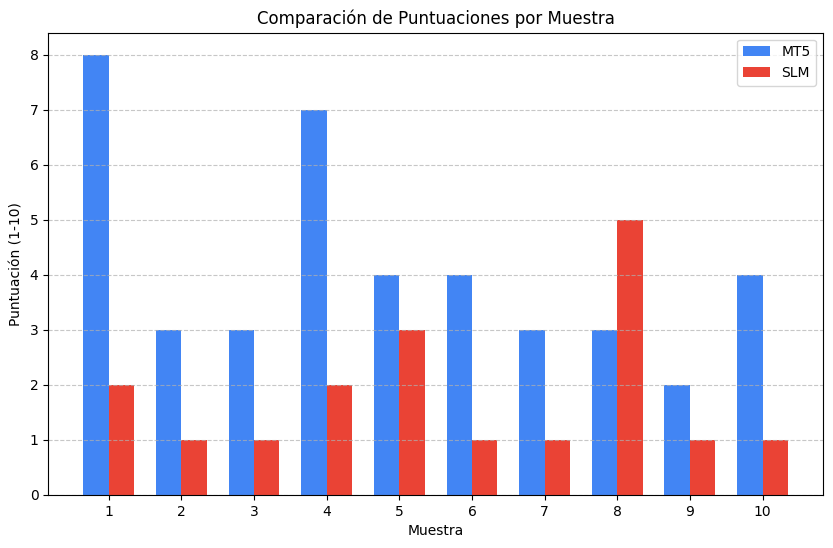

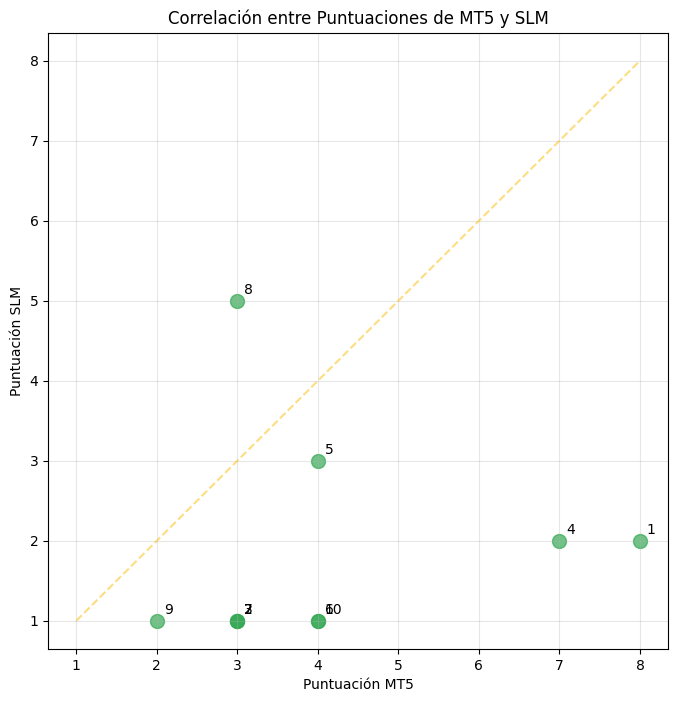

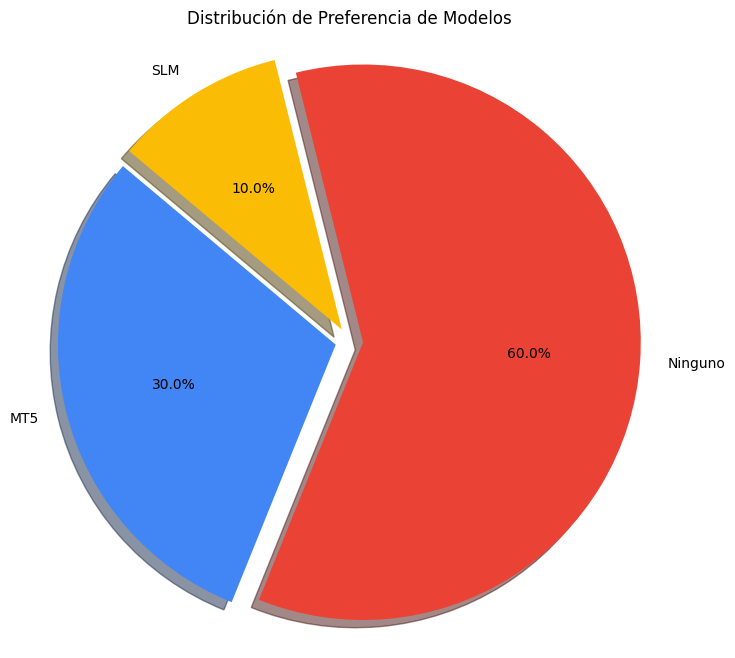


Tabla Comparativa de Evaluaciones:
 Muestra Subreddit  MT5 (Auto)  MT5 (Manual)  SLM (Auto)  SLM (Manual) Mejor (Auto) Mejor (Manual)
       1    sports           1             8           1             2       Empate            MT5
       2    sports           1             3           1             1       Empate        Ninguno
       3       nfl           1             3           1             1       Empate        Ninguno
       4       nba           1             7           1             2       Empate            MT5
       5       nba           1             4           1             3       Empate        Ninguno
       6    soccer           1             4           1             1       Empate        Ninguno
       7       nfl           1             3           1             1       Empate        Ninguno
       8    soccer           1             3           1             5       Empate            SLM
       9    soccer           1             2           1             1   

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Función para crear visualizaciones de los resultados de la evaluación
def create_visualizations(save_files=False):
    # Verificar que el archivo existe
    json_file = 'summary_evaluation_completed.json'
    if not os.path.exists(json_file):
        print(f"Error: No se encontró el archivo {json_file}")
        print("Primero debe ejecutar la herramienta de evaluación.")
        return

    try:
        # Cargar los datos
        with open(json_file, 'r', encoding='utf-8') as f:
            samples = json.load(f)

        print(f"Generando visualizaciones para {len(samples)} muestras...")

        # Crear directorio para gráficos si se van a guardar
        if save_files:
            os.makedirs('evaluation_charts', exist_ok=True)

        # Preparar datos
        mt5_scores = [s['evaluation']['mt5_quality_manual'] for s in samples]
        slm_scores = [s['evaluation']['slm_quality_manual'] for s in samples]

        # 1. Gráfico de barras comparativo
        plt.figure(figsize=(10, 6))
        indices = range(len(samples))
        width = 0.35

        plt.bar([i - width/2 for i in indices], mt5_scores, width, label='MT5', color='#4285F4')
        plt.bar([i + width/2 for i in indices], slm_scores, width, label='SLM', color='#EA4335')

        plt.xlabel('Muestra')
        plt.ylabel('Puntuación (1-10)')
        plt.title('Comparación de Puntuaciones por Muestra')
        plt.xticks(indices, [f"{i+1}" for i in indices])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        if save_files:
            plt.savefig('evaluation_charts/score_comparison.png', dpi=300, bbox_inches='tight')

        plt.show()  # Mostrar gráfico en pantalla

        # 2. Gráfico de dispersión
        plt.figure(figsize=(8, 8))
        plt.scatter(mt5_scores, slm_scores, alpha=0.7, s=100, c='#34A853')

        # Añadir línea diagonal
        max_score = max(max(mt5_scores), max(slm_scores))
        min_score = min(min(mt5_scores), min(slm_scores))
        plt.plot([min_score, max_score], [min_score, max_score], '--', color='#FBBC05', alpha=0.5)

        plt.xlabel('Puntuación MT5')
        plt.ylabel('Puntuación SLM')
        plt.title('Correlación entre Puntuaciones de MT5 y SLM')
        plt.grid(True, alpha=0.3)

        # Añadir etiquetas a cada punto
        for i, (x, y) in enumerate(zip(mt5_scores, slm_scores)):
            plt.annotate(f"{i+1}", (x, y), xytext=(5, 5), textcoords='offset points')

        if save_files:
            plt.savefig('evaluation_charts/score_correlation.png', dpi=300, bbox_inches='tight')

        plt.show()  # Mostrar gráfico en pantalla

        # 3. Gráfico circular para "mejor modelo"
        best_models = {}
        for s in samples:
            best = s['evaluation']['best_model_manual']
            best_models[best] = best_models.get(best, 0) + 1

        plt.figure(figsize=(8, 8))
        colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']

        labels = list(best_models.keys())
        sizes = list(best_models.values())

        plt.pie(sizes, labels=labels, colors=colors[:len(labels)], autopct='%1.1f%%',
                shadow=True, startangle=140, explode=[0.05]*len(labels))
        plt.axis('equal')
        plt.title('Distribución de Preferencia de Modelos')

        if save_files:
            plt.savefig('evaluation_charts/model_preference.png', dpi=300, bbox_inches='tight')

        plt.show()  # Mostrar gráfico en pantalla

        # 4. Tabla comparativa
        data = []
        for i, s in enumerate(samples):
            data.append({
                'Muestra': i+1,
                'Subreddit': s['subreddit'],
                'MT5 (Auto)': s['mt5_quality'],
                'MT5 (Manual)': s['evaluation']['mt5_quality_manual'],
                'SLM (Auto)': s['slm_quality'],
                'SLM (Manual)': s['evaluation']['slm_quality_manual'],
                'Mejor (Auto)': s['best_model_auto'],
                'Mejor (Manual)': s['evaluation']['best_model_manual'],
            })

        df = pd.DataFrame(data)

        # Mostrar tabla en formato legible
        print("\nTabla Comparativa de Evaluaciones:")
        print(df.to_string(index=False))

        if save_files:
            # Guardar como CSV
            df.to_csv('evaluation_charts/comparison_table.csv', index=False)

        # 5. Estadísticas descriptivas
        print("\nESTADÍSTICAS DE LA EVALUACIÓN")
        print("============================\n")

        print("Puntuaciones de MT5:")
        print(f"  - Promedio: {np.mean(mt5_scores):.2f}")
        print(f"  - Mediana: {np.median(mt5_scores):.2f}")
        print(f"  - Desviación estándar: {np.std(mt5_scores):.2f}")
        print(f"  - Mínimo: {min(mt5_scores)}")
        print(f"  - Máximo: {max(mt5_scores)}\n")

        print("Puntuaciones de SLM:")
        print(f"  - Promedio: {np.mean(slm_scores):.2f}")
        print(f"  - Mediana: {np.median(slm_scores):.2f}")
        print(f"  - Desviación estándar: {np.std(slm_scores):.2f}")
        print(f"  - Mínimo: {min(slm_scores)}")
        print(f"  - Máximo: {max(slm_scores)}\n")

        # Pruebas estadísticas
        print("Comparación Estadística:")

        # Test t pareado
        from scipy import stats
        t_stat, p_value = stats.ttest_rel(mt5_scores, slm_scores)
        print(f"  - Test t pareado: t={t_stat:.4f}, p={p_value:.4f}")

        if p_value < 0.05:
            if np.mean(mt5_scores) > np.mean(slm_scores):
                print("    * Resultado: MT5 es significativamente mejor que SLM")
            else:
                print("    * Resultado: SLM es significativamente mejor que MT5")
        else:
            print("    * Resultado: No hay diferencia estadísticamente significativa")

        # Correlación
        corr, p = stats.pearsonr(mt5_scores, slm_scores)
        print(f"  - Correlación de Pearson: r={corr:.4f}, p={p:.4f}")

        if p < 0.05:
            if corr > 0:
                print("    * Las puntuaciones de ambos modelos están correlacionadas positivamente")
            else:
                print("    * Las puntuaciones de ambos modelos están correlacionadas negativamente")
        else:
            print("    * No hay correlación significativa entre las puntuaciones")

        if save_files:
            # También guardar las estadísticas en un archivo
            with open('evaluation_charts/statistics.txt', 'w', encoding='utf-8') as f:
                f.write("ESTADÍSTICAS DE LA EVALUACIÓN\n")
                f.write("============================\n\n")

                f.write("Puntuaciones de MT5:\n")
                f.write(f"  - Promedio: {np.mean(mt5_scores):.2f}\n")
                f.write(f"  - Mediana: {np.median(mt5_scores):.2f}\n")
                f.write(f"  - Desviación estándar: {np.std(mt5_scores):.2f}\n")
                f.write(f"  - Mínimo: {min(mt5_scores)}\n")
                f.write(f"  - Máximo: {max(mt5_scores)}\n\n")

                f.write("Puntuaciones de SLM:\n")
                f.write(f"  - Promedio: {np.mean(slm_scores):.2f}\n")
                f.write(f"  - Mediana: {np.median(slm_scores):.2f}\n")
                f.write(f"  - Desviación estándar: {np.std(slm_scores):.2f}\n")
                f.write(f"  - Mínimo: {min(slm_scores)}\n")
                f.write(f"  - Máximo: {max(slm_scores)}\n\n")

                f.write("Comparación Estadística:\n")
                f.write(f"  - Test t pareado: t={t_stat:.4f}, p={p_value:.4f}\n")

                if p_value < 0.05:
                    if np.mean(mt5_scores) > np.mean(slm_scores):
                        f.write("    * Resultado: MT5 es significativamente mejor que SLM\n")
                    else:
                        f.write("    * Resultado: SLM es significativamente mejor que MT5\n")
                else:
                    f.write("    * Resultado: No hay diferencia estadísticamente significativa\n")

                f.write(f"  - Correlación de Pearson: r={corr:.4f}, p={p:.4f}\n")

                if p < 0.05:
                    if corr > 0:
                        f.write("    * Las puntuaciones de ambos modelos están correlacionadas positivamente\n")
                    else:
                        f.write("    * Las puntuaciones de ambos modelos están correlacionadas negativamente\n")
                else:
                    f.write("    * No hay correlación significativa entre las puntuaciones\n")

            print("Visualizaciones generadas con éxito en la carpeta 'evaluation_charts'")
        else:
            print("Visualizaciones mostradas con éxito (no se guardaron archivos)")

    except Exception as e:
        print(f"Error al generar visualizaciones: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    # Ejecutar la función sin guardar archivos (solo mostrar)
    create_visualizations(save_files=False)

Con base en las evaluaciones cualitativas y cuantitativas entre los modelos hemos generado una serie de estadísticas para poder comprender mejor que es lo que ocurre y qué diferencia encontramos entre los modelos MT5 y SLM:

Los datos indican que aunque todos los resumenes tienen una puntuación de 1 (es válido y coherente) en la evaluación automática, en la evaluación manual esto no es así, "no todo es tan perfecto". En la evaluación manual entra en juego el pensamiento y razonamiento humano, lo que nos permite detectar diferencias de calidad, precisión y relevancia entre los resúmenes generados por MT5 y los de SLM. Es decir, esta evaluación automatica utilizada es poco sensible a aspectos cualitativos clave.

Las estadísticas de la evaluación manual muestran que los resúmenes generados por MT5 obtuvieron puntuaciones manuales significativamente mejores que los de SLM, con un promedio de 4.10 frente a 1.80 y una diferencia estadísticamente significativa (p=0.0094). Esto indica que, en general, los resúmenes de MT5 son percibidos como más coherentes, relevantes y con mejor contenido en comparación con los de SLM. Además, la mayor dispersión en las puntuaciones de MT5 (desviación estándar de 1.81 versus 1.25 en SLM) sugiere que su calidad varía más entre muestras, posiblemente porque MT5 a veces genera resúmenes bastante buenos y en otras ocasiones más pobres, mientras que SLM tiende a generar textos consistentemente bajos o repetitivos. La falta de correlación significativa entre ambas puntuaciones indica que la calidad percibida de un resumen en un modelo no predice la calidad en el otro, apuntando a que cada modelo comete errores distintos. En conjunto, estos resultados refuerzan la preferencia manual por MT5 para la tarea de resumen en estos ejemplos, aunque aún hay margen para mejorar la consistencia y calidad en ambos.

Sin embargo, estos resultados no nos sorprenden si entendemos cómo funciona cada modelo y el tipo de datos que procesan:

Los resúmenes generados por modelos como Gemma tienden a ser más extensos porque son modelos autorregresivos que generan texto palabra por palabra, lo que genera salidas verbosas si no se limita (el límite es 40). Además, el estilo de Prompting Zero-shot hace que el modelo no esté entrenado para resumir, y como resultado lo que vemos es que tiende a replicar comentarios enteros o continuar ideas en lugar de condensarlas. En contraste, MT5 está preentrenado para tareas de resumen multilingüe, por lo que su objetivo es condensar. Por eso, tiende a generar frases más coherentes y bien estructuradas y a seleccionar la información clave del texto de entrada. Aunque en ocasiones, en los ejemplos que hemos podido analizar no ha realizado buenos resúmenes, la tarea de estos modelos sí es el resumen automático. La causa de que falle en esta tarea se puede deber a la naturaleza del contenido de entrada. MT5 está estructurado para resumir textos bien estructurados, como noticias, artículos o documentos formales. Sin embargo, los hilos de Reddit pueden contener lenguaje informal, falta de una estructura clara, la información relevante puede estar mezclada entre diferentes comentarios, mientras que otros puede ser que no aporten nada, incluso que contengan información falsa o que conlleva una interpretación errónea del modelo.

Por tanto, aunque MT5 está diseñado para realizar resúmenes, su rendimiento disminuye cuando se enfrenta a texto ruidoso o conversacional que no se asemeja a los datos con los que fue entrenado. Esto explica por qué, a pesar de su diseño, su rendimiento manual no ha sido muy alto.

Otro aspecto relevante a comentar son los resúmenes vacíos que produce el modelo SLM. Estos resúmenes podrían surgir cuando el modelo no detecta información relevante clara para condensar, optando por generar poco o ningún texto en lugar de inventar contenido, o bien cuando se produce un fallo interno en el proceso de generación que interrumpe la salida. Esta conducta indica que SLM es sensible a la calidad y estructura del texto de entrada y que sin ajustes finos, ni instrucciones claras, su generación puede resultar errática, poco informativa o redundante. Esto limita su utilidad para resumir contenido complejo y heterogéneo como los hilos de Reddit, donde la señal y el ruido están muy mezclados.

Otro hecho que hemos podido apreciar es que los modelos producen afirmaciones falsas o alucinaciones. Esto ocurre sobre todo por lo que ya hemos comentado, algunos comentarios contienen información errónea, sarcasmo o especulación que el modelo no distingue como tales. Sucede en ambos modelos pero en especial en MT5.

A pesar de las diferencias en estilo y rendimiento entre MT5 y SLM, ninguno de los dos modelos puede considerarse plenamente eficiente para la tarea de resumir contenido de Reddit. MT5, aunque especializado en resumen, falla al enfrentarse a texto informal, no estructurado y altamente contextual como el que se encuentra en foros en línea. Por otro lado, SLM no realiza una verdadera condensación de la información; más bien, reproduce o reformula partes de los comentarios, incluyendo opiniones, quejas o incluso contenido irrelevante. Además, ambos modelos presentan problemas importantes con la veracidad de lo que generan, incorporando afirmaciones falsas o fuera de contexto. Esto sugiere que, para lograr resúmenes precisos y útiles en entornos como Reddit, se necesitarían enfoques más robustos, posiblemente entrenados específicamente para lidiar con la complejidad, ruido y subjetividad del contenido generado por usuarios.
